# Project:getting data of telangana and karnataka states from meteostat 

## 1. Importing Necessary Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

import warnings
# to display all columns and rows:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None);  # to display all columns and rows
pd.set_option('display.float_format', lambda x: '%.2f' % x) # The number of numbers that will be shown after the comma.


## 2. Loading the Data

In [2]:
from meteostat import Point, Daily
from datetime import datetime
import pandas as pd

# Coordinates for Telangana and Karnataka
states_coords = {
    "Telangana": (17.1232, 79.2088),  # Coordinates for Telangana
    "Karnataka": (15.3173, 75.7139)   # Coordinates for Karnataka
}

# Define time period: Last 1 year (instead of 3 years)
end_date = datetime.now()
start_date = end_date.replace(year=end_date.year - 2)

# Initialize an empty DataFrame to store the combined data
all_states_data = pd.DataFrame()

# Loop through each state and fetch data
for state, (lat, lon) in states_coords.items():
    # Define the location based on latitude and longitude
    location = Point(lat, lon)
    
    # Fetch daily weather data for the defined period
    data = Daily(location, start_date, end_date).fetch()
    
    # Check if data exists for the location
    if not data.empty:
        # Add state name to the data
        data["state"] = state
        
        # Append the data to the final DataFrame
        all_states_data = pd.concat([all_states_data, data])
    else:
        print(f"No data found for {state} in the last year.")

# Print the first few rows of the final DataFrame
print(all_states_data.head())



            tavg  tmin  tmax  prcp  snow   wdir  wspd  wpgt    pres  tsun  \
time                                                                        
2023-01-12 23.10 15.30 32.10  0.00   NaN  82.00  6.20   NaN 1011.60   NaN   
2023-01-13 24.60 18.80 32.00  0.00   NaN 116.00  7.10   NaN 1012.00   NaN   
2023-01-14 24.60 19.10 32.10  0.00   NaN 115.00  7.00   NaN 1011.90   NaN   
2023-01-15 24.50 17.10 31.80  0.00   NaN  84.00  7.20   NaN 1011.10   NaN   
2023-01-16 24.30 17.30 32.20  0.00   NaN 132.00  8.70   NaN 1011.80   NaN   

                state  
time                   
2023-01-12  Telangana  
2023-01-13  Telangana  
2023-01-14  Telangana  
2023-01-15  Telangana  
2023-01-16  Telangana  


In [3]:
df=all_states_data
df.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,state
time,,,,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,NaN,82.00,6.20,NaN,1011.60,NaN,Telangana
2023-01-13,24.60,18.80,32.00,0.00,NaN,116.00,7.10,NaN,1012.00,NaN,Telangana
2023-01-14,24.60,19.10,32.10,0.00,NaN,115.00,7.00,NaN,1011.90,NaN,Telangana
2023-01-15,24.50,17.10,31.80,0.00,NaN,84.00,7.20,NaN,1011.10,NaN,Telangana
2023-01-16,24.30,17.30,32.20,0.00,NaN,132.00,8.70,NaN,1011.80,NaN,Telangana


# 3. Data Analysis

## 3.1 Displaying top 5 rows

In [4]:
df.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,state
time,,,,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,NaN,82.00,6.20,NaN,1011.60,NaN,Telangana
2023-01-13,24.60,18.80,32.00,0.00,NaN,116.00,7.10,NaN,1012.00,NaN,Telangana
2023-01-14,24.60,19.10,32.10,0.00,NaN,115.00,7.00,NaN,1011.90,NaN,Telangana
2023-01-15,24.50,17.10,31.80,0.00,NaN,84.00,7.20,NaN,1011.10,NaN,Telangana
2023-01-16,24.30,17.30,32.20,0.00,NaN,132.00,8.70,NaN,1011.80,NaN,Telangana


## 3.2 Displaying botton 5 rows

In [5]:
df.tail()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,state
time,,,,,,,,,,,
2025-01-07,22.50,16.20,29.10,0.00,NaN,108.00,12.00,NaN,1013.20,NaN,Karnataka
2025-01-08,22.40,17.10,28.10,0.00,NaN,92.00,13.10,NaN,1013.20,NaN,Karnataka
2025-01-09,21.60,16.10,27.50,0.00,NaN,97.00,14.70,NaN,1014.10,NaN,Karnataka
2025-01-10,22.40,17.10,27.80,0.00,NaN,105.00,15.30,NaN,1015.20,NaN,Karnataka
2025-01-11,23.10,17.70,29.60,0.00,NaN,121.00,15.20,NaN,1014.70,NaN,Karnataka


## 3.3 Displaying shape of the Dataset

In [6]:
s=df.shape
print('total number of rows:', s[0])
print('total number of columns:',s[1])

total number of rows: 1462
total number of columns: 11


## 3.4 information of dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2023-01-12 to 2025-01-11
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tavg    1451 non-null   float64
 1   tmin    1451 non-null   float64
 2   tmax    1450 non-null   float64
 3   prcp    1451 non-null   float64
 4   snow    0 non-null      float64
 5   wdir    1442 non-null   float64
 6   wspd    1442 non-null   float64
 7   wpgt    0 non-null      float64
 8   pres    1442 non-null   float64
 9   tsun    0 non-null      float64
 10  state   1462 non-null   object 
dtypes: float64(10), object(1)
memory usage: 137.1+ KB


## 3.5 display column name

In [8]:
df.columns

Index(['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres',
       'tsun', 'state'],
      dtype='object')

## 3.6 Finding duplicates

In [9]:
print('any duplicates in dataset:', df.duplicated().sum().any())

any duplicates in dataset: True


In [10]:
print('total no of duplicates iin dataset:',df.duplicated().sum().sum())

total no of duplicates iin dataset: 9


## removing unnecessary columns

In [11]:
columns_to_remove = ['snow', 'wpgt', 'tsun']
df = df.drop(columns=columns_to_remove)

# Print the updated DataFrame
df.head()

,tavg,tmin,tmax,prcp,wdir,wspd,pres,state
time,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana
2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana
2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana
2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana
2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana


In [12]:
print('total no of duplicates iin dataset:',df.duplicated().sum())

total no of duplicates iin dataset: 9


## dropping the duplicates

In [13]:
# Drop duplicate rows
df = df.drop_duplicates()
df.duplicated().sum()

0

## 3.7 Finding Null values

In [14]:
print('any null values in dataset:', df.isnull().sum().any())

any null values in dataset: True


In [15]:
print('Total no of null values in dataset:', df.isnull().sum().sum())

Total no of null values in dataset: 42


In [16]:
df.isnull().sum()

tavg      2
tmin      2
tmax      3
prcp      2
wdir     11
wspd     11
pres     11
state     0
dtype: int64

## Replacing the null values with mean

In [17]:


# Drop the 'state' column temporarily for processing
df_without_state = df.drop(columns=['state'])

# Iterate through each column and replace NaN values with the mean of that column
for column in df_without_state.columns:
    df_without_state[column].fillna(df_without_state[column].mean(), inplace=True)

# Combine the 'state' column back with the processed DataFrame
df_without_state['state'] = df['state']

# Print the updated DataFrame excluding the state column in the output
print(df_without_state.head())

            tavg  tmin  tmax  prcp   wdir  wspd    pres      state
time                                                              
2023-01-12 23.10 15.30 32.10  0.00  82.00  6.20 1011.60  Telangana
2023-01-13 24.60 18.80 32.00  0.00 116.00  7.10 1012.00  Telangana
2023-01-14 24.60 19.10 32.10  0.00 115.00  7.00 1011.90  Telangana
2023-01-15 24.50 17.10 31.80  0.00  84.00  7.20 1011.10  Telangana
2023-01-16 24.30 17.30 32.20  0.00 132.00  8.70 1011.80  Telangana


In [18]:
df=df_without_state

In [19]:
df.head()

,tavg,tmin,tmax,prcp,wdir,wspd,pres,state
time,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana
2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana
2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana
2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana
2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana


In [20]:
df.shape

(1453, 8)

## 3.8 display datatypes of each columns

In [21]:
df.dtypes

tavg     float64
tmin     float64
tmax     float64
prcp     float64
wdir     float64
wspd     float64
pres     float64
state     object
dtype: object

# Note*: By observing the data

## Continous columns

tavg
tmin
tmax
prcp
wdir
wspd
pres


## categorical columns

1.state

## 3.9 Statistical analysis of dataset

In [22]:
df.describe()

,tavg,tmin,tmax,prcp,wdir,wspd,pres
count,1453.00,1453.00,1453.00,1453.00,1453.00,1453.00,1453.00
mean,27.59,22.08,33.53,2.44,177.55,11.38,1009.44
std,3.22,3.14,3.88,6.94,96.29,4.18,3.61
min,20.90,13.30,25.20,0.00,0.00,4.10,998.80
25%,24.90,20.00,30.50,0.00,93.00,8.20,1006.80
50%,27.40,21.60,33.10,0.00,158.00,10.30,1009.50
75%,29.60,24.60,36.10,1.30,264.00,13.60,1012.20
max,37.50,31.90,45.60,84.70,359.00,25.90,1017.70


In [23]:
df.columns

Index(['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'state'], dtype='object')

In [24]:
df[['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']].describe().T

,count,mean,std,min,25%,50%,75%,max
tavg,1453.00,27.59,3.22,20.90,24.90,27.40,29.60,37.50
tmin,1453.00,22.08,3.14,13.30,20.00,21.60,24.60,31.90
tmax,1453.00,33.53,3.88,25.20,30.50,33.10,36.10,45.60
prcp,1453.00,2.44,6.94,0.00,0.00,0.00,1.30,84.70
wdir,1453.00,177.55,96.29,0.00,93.00,158.00,264.00,359.00
wspd,1453.00,11.38,4.18,4.10,8.20,10.30,13.60,25.90
pres,1453.00,1009.44,3.61,998.80,1006.80,1009.50,1012.20,1017.70


## 3.10 relationship between columns

In [25]:
df[['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']].corr()

,tavg,tmin,tmax,prcp,wdir,wspd,pres
tavg,1.00,0.83,0.90,-0.08,0.28,-0.11,-0.53
tmin,0.83,1.00,0.62,0.07,0.33,-0.00,-0.65
tmax,0.90,0.62,1.00,-0.18,0.15,-0.29,-0.34
prcp,-0.08,0.07,-0.18,1.00,0.15,0.17,-0.26
wdir,0.28,0.33,0.15,0.15,1.00,0.37,-0.61
wspd,-0.11,-0.00,-0.29,0.17,0.37,1.00,-0.37
pres,-0.53,-0.65,-0.34,-0.26,-0.61,-0.37,1.00


## 4. Data cleaning

In [26]:
#here i am not converting the zeroes in the data to nans
#bcz there are so many zeroes in precipitation if i do so all the values will be changed so i am not doing this step

## Rechecking the nulls

### Finding each column how many null values count

In [27]:
df.isnull().sum()

tavg     0
tmin     0
tmax     0
prcp     0
wdir     0
wspd     0
pres     0
state    0
dtype: int64

In [28]:
#there are no nulls in the data

## Distribution of the Categorical Column: state

### How many non unique values are there

In [29]:
df['state'].nunique()

2

### What are those categories names

In [30]:
df['state'].unique()

array(['Telangana', 'Karnataka'], dtype=object)

### Each Category how many records are there

In [31]:
df['state'].value_counts()

state
Karnataka    731
Telangana    722
Name: count, dtype: int64

### Calculating the Percentage

In [32]:
df["state"].value_counts()*100/len(df)

state
Karnataka   50.31
Telangana   49.69
Name: count, dtype: float64

In [33]:
###replacing the nulls i have already done above 

## Checking outliers using statistical methods

In [34]:
# Detect outliers for each numeric column
outliers = pd.DataFrame()

for col in df.select_dtypes(include='number').columns:
    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter outliers
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # Append to outliers DataFrame
    outliers = pd.concat([outliers, col_outliers])
    
    # Print details for each column
    print(f'Outliers in {col}:')
    print(col_outliers)
    print(f'Count of outliers in {col}: {len(col_outliers)}\n')

# Print total unique outliers (if needed)
outliers = outliers.drop_duplicates()
print('Total Unique Outliers:')
print(outliers)
print(f'Total Count of Unique Outliers: {len(outliers)}')


Outliers in tavg:
            tavg  tmin  tmax  prcp   wdir  wspd    pres      state
time                                                              
2024-05-01 37.50 29.60 45.60  0.00 186.00 12.20 1002.70  Telangana
2024-05-31 36.70 28.00 44.20  0.00 328.00  9.50 1002.10  Telangana
Count of outliers in tavg: 2

Outliers in tmin:
            tavg  tmin  tmax  prcp   wdir  wspd   pres      state
time                                                             
2024-05-27 36.00 31.90 41.70  4.20 270.00 20.90 999.20  Telangana
Count of outliers in tmin: 1

Outliers in tmax:
            tavg  tmin  tmax  prcp   wdir  wspd    pres      state
time                                                              
2024-04-28 35.80 28.00 44.80  0.00 128.00  9.30 1006.10  Telangana
2024-05-01 37.50 29.60 45.60  0.00 186.00 12.20 1002.70  Telangana
2024-05-02 36.30 28.00 44.80  0.00  53.00  9.50 1003.00  Telangana
2024-05-04 36.20 29.70 44.80  0.00 101.00 10.00 1004.60  Telangana
Count of outliers 

## Handling the outliers

In [35]:
# Replace outliers with the median and count remaining outliers
outliers_after = 0

for col in df.select_dtypes(include='number').columns:
    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Calculate median
    median = df[col].median()
    
    # Replace outliers with median
    df[col] = df[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    
    # Count remaining outliers
    outliers_after += len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

print(f'Count of outliers after replacement: {outliers_after}')


Count of outliers after replacement: 0


# 5. EDA

## creating function for continous data statistical analysis

In [36]:
def display_analysis_updated(column):
    try:
        # Create subplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # KDE plot
        sns.kdeplot(df[column].dropna(), ax=axes[0], fill=True, color='skyblue')
        axes[0].set_title(f'Distribution of {column} (KDE)')
        
        # Box plot
        sns.boxplot(df[column].dropna(), ax=axes[1], color='lightgreen')
        axes[1].set_title(f'{column} Box Plot')
        
        # Display plots
        plt.tight_layout()
        plt.show()
        
        # Calculate skewness and kurtosis
        skewness = df[column].skew()
        kurtosis = df[column].kurtosis()
        mini = df[column].min()
        maxi = df[column].max()
        Q1 = df[column].quantile(0.25)
        Q2 = df[column].quantile(0.5)
        Q3 = df[column].quantile(0.75)
        
        IQR = Q3 - Q1
        LLP = Q1 - 1.5*IQR
        ULP = Q3 + 1.5*IQR
        
        return skewness, kurtosis, mini, maxi, Q1, Q2, Q3, IQR, LLP, ULP
    except Exception as e:
        print(f"Error processing column {column}: {e}")
        return None, None, None, None, None, None, None, None, None, None

## creating function for categorical data statistical analysis

In [37]:
def plot_column_distribution(df, column_name):
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' does not exist in the DataFrame.")
        return

    # Compute unique values, counts, and percentages
    unique_count = df[column_name].nunique()
    unique_values = df[column_name].unique()
    value_counts = df[column_name].value_counts()
    value_percentages = df[column_name].value_counts() * 100 / len(df)

    print(f"Unique values in '{column_name}': {unique_values}")
    print(f"Number of unique values in '{column_name}': {unique_count}")

    # Set up the subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    value_counts.sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'Frequency of {column_name}')
    axes[0].set_xlabel(f'{column_name}')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Pie chart
    value_percentages.plot(
        kind='pie',
        autopct='%1.1f%%',
        startangle=90,
        cmap='viridis',
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title(f'Distribution of {column_name} (%)')
    axes[1].set_ylabel('')  # Hide y-label for better visualization

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()


## 5.1 Continuous data Analysis


Analysis for tavg:


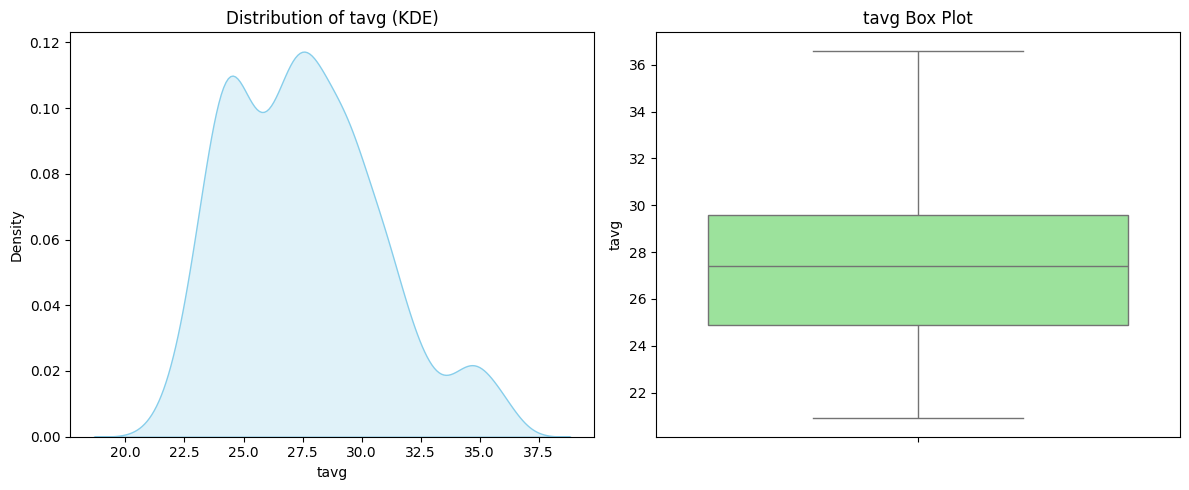


Analysis for tmin:


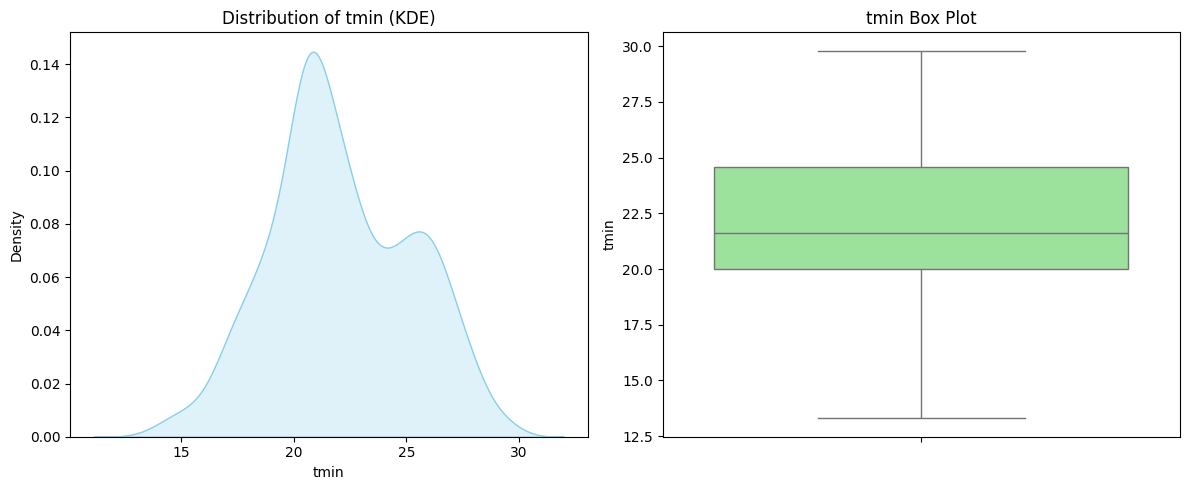


Analysis for tmax:


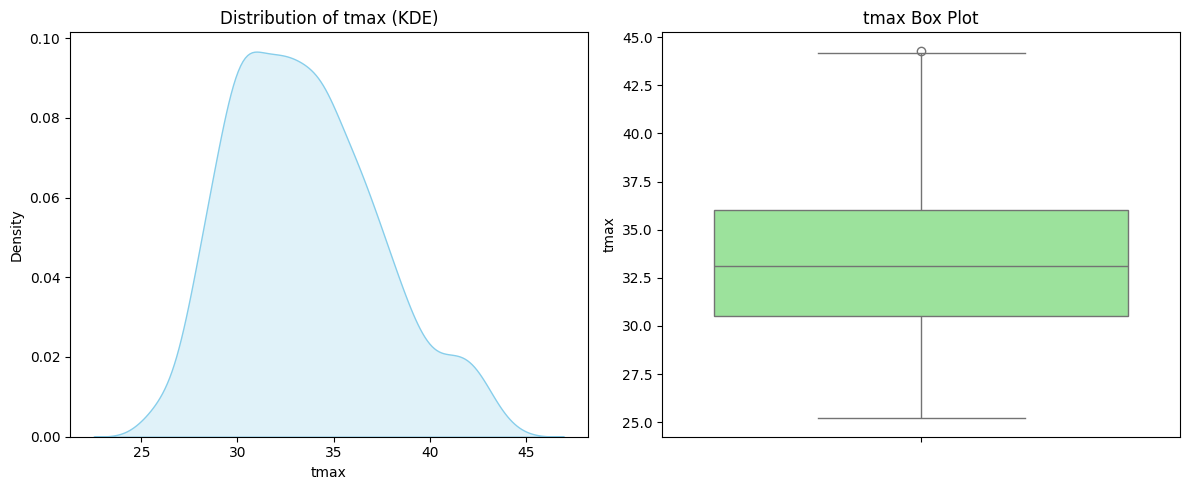


Analysis for prcp:


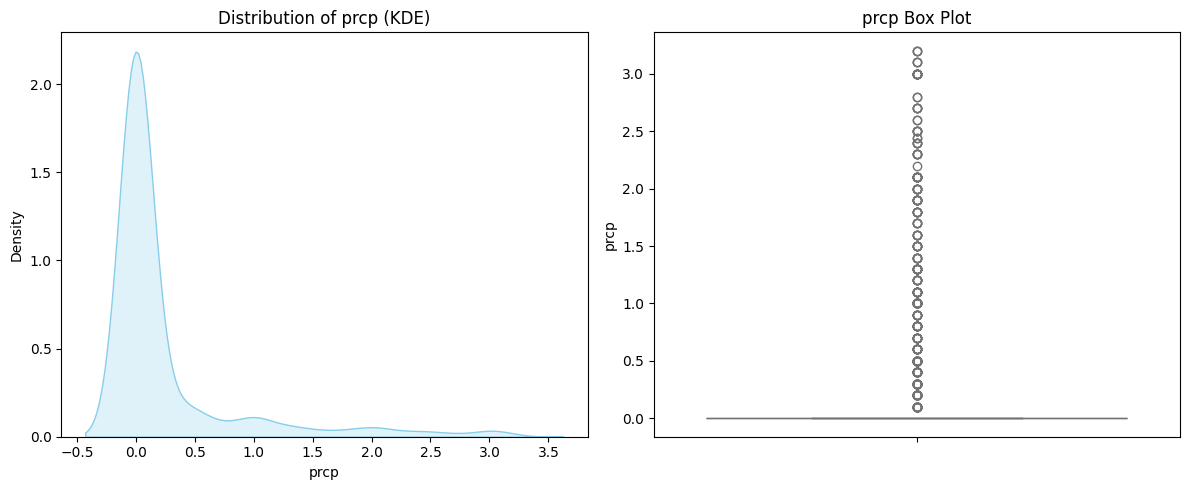


Analysis for wdir:


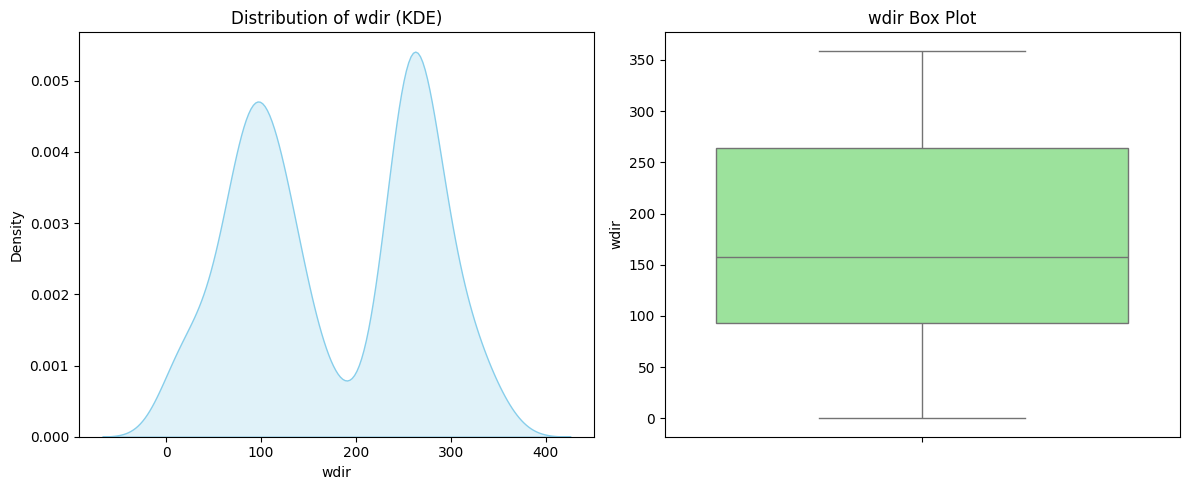


Analysis for wspd:


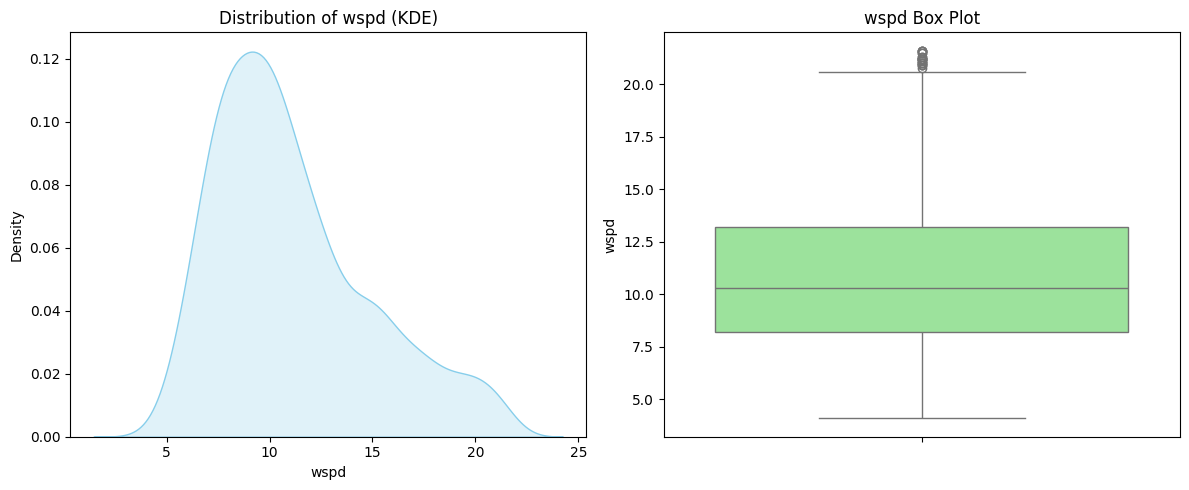


Analysis for pres:


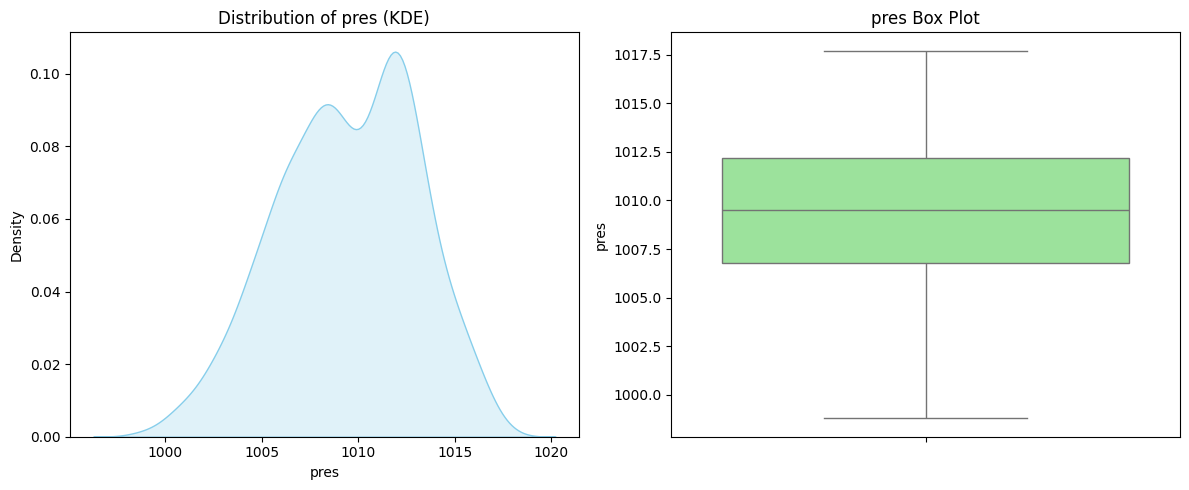


Skewness and Kurtosis Analysis:


,Skewness,Kurtosis,Minimum,Maximum,Q1,Q2,Q3,IQR,LLP,ULP
tavg,0.51,-0.21,20.90,36.60,24.90,27.40,29.60,4.70,17.85,36.65
tmin,0.10,-0.52,13.30,29.80,20.00,21.60,24.60,4.60,13.10,31.50
tmax,0.46,-0.30,25.20,44.30,30.50,33.10,36.00,5.50,22.25,44.25
prcp,2.86,7.90,0.00,3.20,0.00,0.00,0.00,0.00,0.00,0.00
wdir,-0.03,-1.42,0.00,359.00,93.00,158.00,264.00,171.00,-163.50,520.50
wspd,0.82,0.01,4.10,21.60,8.20,10.30,13.20,5.00,0.70,20.70
pres,-0.25,-0.52,998.80,1017.70,1006.80,1009.50,1012.20,5.40,998.70,1020.30


In [38]:
# Apply the updated function to the specified columns
columns_to_check = ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres'] 
results = {}

for column in columns_to_check:
    print(f"\nAnalysis for {column}:")
    skew, kurt,mini,maxi,Q1,Q2,Q3,IQR,LLP,ULP = display_analysis_updated(column)
    if skew is not None and kurt is not None:
        results[column] = {'Skewness': skew, 'Kurtosis': kurt, 'Minimum': mini, 'Maximum': maxi, 'Q1': Q1, 'Q2': Q2, 'Q3': Q3, 'IQR': IQR, 'LLP': LLP, 'ULP': ULP}


results_df = pd.DataFrame(results).T
results_df.columns = ['Skewness', 'Kurtosis', 'Minimum', 'Maximum', 'Q1', 'Q2', 'Q3', 'IQR', 'LLP', 'ULP']
print("\nSkewness and Kurtosis Analysis:")
results_df

1. Skewness:
Skewness measures the asymmetry of the data distribution. A positive skew means the data tail is longer on the right side, while a negative skew means the tail is longer on the left side.
Interpretation:
For tavg (average temperature), the skewness is 0.52, indicating a slight positive skew (right tail is a bit longer).
For tmin (minimum temperature), the skewness is 0.10, indicating a very slight positive skew.
For tmax (maximum temperature), the skewness is 0.49, indicating a slight positive skew.
For prcp (precipitation), the skewness is 5.60, showing a very high positive skew (there are very few days with a large amount of precipitation, but when it rains, it tends to rain a lot).
For wdir (wind direction), the skewness is -0.03, indicating a very slight negative skew (slightly more occurrences of higher wind directions).
For wspd (wind speed), the skewness is 0.98, showing a moderate positive skew (most wind speeds are low, but some extreme high wind speeds exist).
For pres (pressure), the skewness is -0.25, indicating a slight negative skew.

2. Kurtosis:
Kurtosis measures the "tailedness" or how outliers are distributed in the data. Positive kurtosis means that the data have heavy tails (more outliers), and negative kurtosis means the data have lighter tails (fewer outliers).
Interpretation:
For tavg, the kurtosis is -0.18, indicating that the data have relatively light tails (fewer extreme values).
For tmin, the kurtosis is -0.47, indicating light tails (fewer extreme values).
For tmax, the kurtosis is -0.23, indicating light tails.
For prcp, the kurtosis is 41.46, indicating extremely heavy tails (precipitation data has significant outliers with a few extreme values, such as very high rainfall on rare occasions).
For wdir, the kurtosis is -1.42, suggesting a very flat distribution with fewer extreme values in the data.
For wspd, the kurtosis is 0.46, indicating a relatively normal distribution with moderate tails.
For pres, the kurtosis is -0.52, suggesting light tails (less extreme values).

## 5.2 Categorical data Analysis

Unique values in 'state': ['Telangana' 'Karnataka']
Number of unique values in 'state': 2


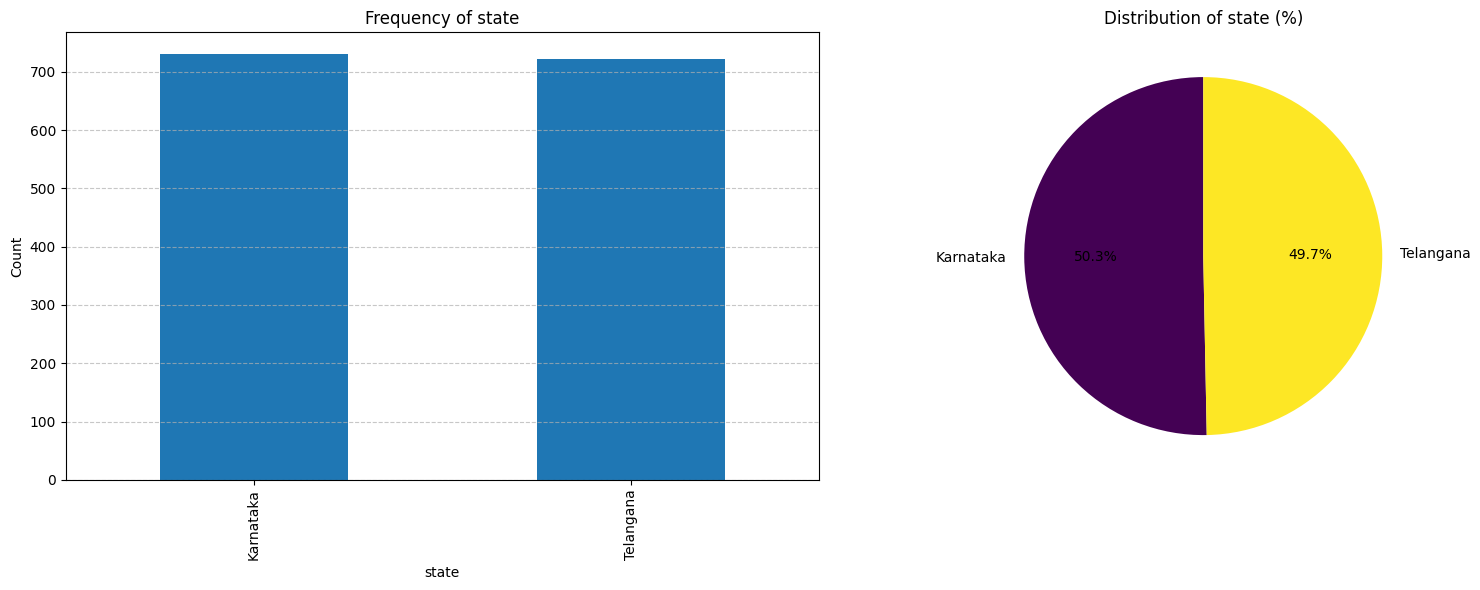

In [39]:
# List of columns to analyze
columns_to_plot = ['state']

# Loop through each column and plot the distribution
for column in columns_to_plot:
    plot_column_distribution(df, column)

In [40]:
df.head()

,tavg,tmin,tmax,prcp,wdir,wspd,pres,state
time,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana
2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana
2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana
2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana
2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana


In [41]:
df.columns

Index(['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'state'], dtype='object')

## 6. Feature Engineering

## 6.1 Converting time column into different categories like month,year 


In [42]:
df.reset_index(inplace=True)  
df.head()


,time,tavg,tmin,tmax,prcp,wdir,wspd,pres,state
0,2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana
1,2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana
2,2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana
3,2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana
4,2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana


In [43]:
# Ensure the 'time' column is a datetime object
# Reset index temporarily to manipulate 'time' column
df['time'] = pd.to_datetime(df['time'])

# Extract features from the 'time' column
df['year'] = df['time'].dt.year       # Extract year
df['month'] = df['time'].dt.month     # Extract month
df['day'] = df['time'].dt.day         # Extract day
df['day_of_week'] = df['time'].dt.dayofweek  # Extract day of the week (0=Monday, 6=Sunday)
df['quarter'] = df['time'].dt.quarter # Extract quarter

# Optional: Reset 'time' as the index again
df.set_index('time', inplace=True)

# Display the first few rows to verify the changes
df.head()


,tavg,tmin,tmax,prcp,wdir,wspd,pres,state,year,month,day,day_of_week,quarter
time,,,,,,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana,2023,1,12,3,1
2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana,2023,1,13,4,1
2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana,2023,1,14,5,1
2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana,2023,1,15,6,1
2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana,2023,1,16,0,1


## correlation between the different features:

Correlation Matrix:
      tavg  tmin  tmax  prcp  wdir  wspd  pres
tavg  1.00  0.82  0.89 -0.03  0.28 -0.05 -0.53
tmin  0.82  1.00  0.61  0.11  0.33  0.02 -0.65
tmax  0.89  0.61  1.00 -0.11  0.15 -0.20 -0.33
prcp -0.03  0.11 -0.11  1.00  0.16  0.20 -0.21
wdir  0.28  0.33  0.15  0.16  1.00  0.35 -0.61
wspd -0.05  0.02 -0.20  0.20  0.35  1.00 -0.35
pres -0.53 -0.65 -0.33 -0.21 -0.61 -0.35  1.00


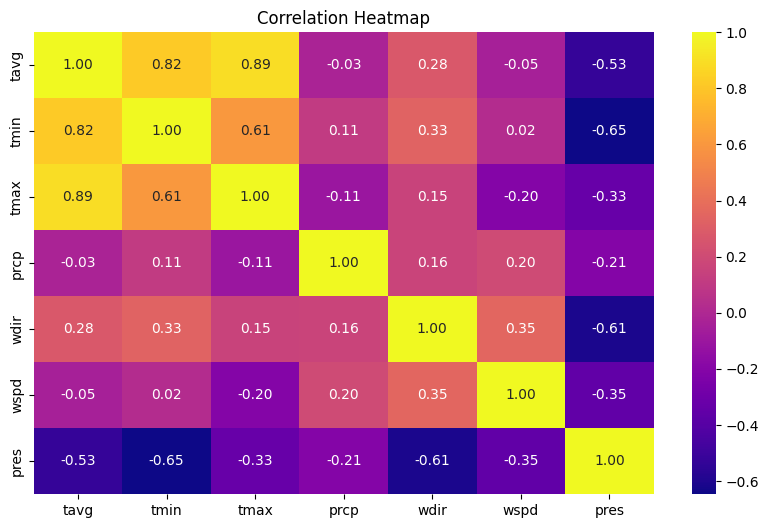

In [44]:
# Select only numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='plasma', cbar=True)
plt.title('Correlation Heatmap')
plt.show()


## Checking stationarity

In [45]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test on each column and check stationarity
def check_stationarity(df):
    stationarity_results = {}

    for col in df.select_dtypes(include='number').columns:
        result = adfuller(df[col].dropna())  # Drop NA values before performing ADF test
        stationarity_results[col] = {
            'ADF Statistic': result[0],
            'p-value': result[1],
            'Stationary': result[1] <= 0.05  # p-value <= 0.05 means the series is stationary
        }
    
    return stationarity_results

# Get stationarity results
stationarity_results = check_stationarity(df)

# Print the results
for col, result in stationarity_results.items():
    print(f"Column: {col}")
    print(f"  ADF Statistic: {result['ADF Statistic']}")
    print(f"  p-value: {result['p-value']}")
    print(f"  Stationary: {result['Stationary']}")
    print('-' * 40)


Column: tavg
  ADF Statistic: -2.222173817311019
  p-value: 0.1982962880032863
  Stationary: False
----------------------------------------
Column: tmin
  ADF Statistic: -2.110243896444577
  p-value: 0.24041548033550642
  Stationary: False
----------------------------------------
Column: tmax
  ADF Statistic: -2.7887212880718133
  p-value: 0.05990300034079624
  Stationary: False
----------------------------------------
Column: prcp
  ADF Statistic: -10.041939882907734
  p-value: 1.488333801160377e-17
  Stationary: True
----------------------------------------
Column: wdir
  ADF Statistic: -3.8601536383428274
  p-value: 0.002348471083090846
  Stationary: True
----------------------------------------
Column: wspd
  ADF Statistic: -3.929386861529756
  p-value: 0.0018289109623803562
  Stationary: True
----------------------------------------
Column: pres
  ADF Statistic: -2.5912369578328174
  p-value: 0.09482196952150046
  Stationary: False
----------------------------------------
Column: 

## Transforming the data and rechecking stationarity 

In [46]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Assuming df is your DataFrame with the specified columns
columns_to_stationarize = ['tavg', 'tmin', 'tmax', 'pres', 'year']

# Create a new DataFrame to store stationary series
stationary_df = pd.DataFrame(index=df.index)

# Perform first differencing on each column
for column in columns_to_stationarize:
    stationary_df[column] = df[column].diff()

# Drop the first row since differencing creates NaN
stationary_df = stationary_df.dropna()

# Print results to verify
print("Stationary DataFrame:")
print(stationary_df.head())

# Check stationarity using ADF test and determine if each column is stationary
for column in stationary_df.columns:
    result = adfuller(stationary_df[column])
    adf_statistic = result[0]
    p_value = result[1]
    critical_values = result[4]
    
    # Determine if the column is stationary
    if p_value < 0.05 and adf_statistic < critical_values['5%']:
        status = "Stationary"
    else:
        status = "Not Stationary"
    
    # Print the results
    print(f"Column: {column}")
    print(f"ADF Statistic: {adf_statistic}")
    print(f"p-value: {p_value}")
    print(f"Critical Values: {critical_values}")
    print(f"Status: {status}")
    print("\n")


Stationary DataFrame:
            tavg  tmin  tmax  pres  year
time                                    
2023-01-13  1.50  3.50 -0.10  0.40  0.00
2023-01-14  0.00  0.30  0.10 -0.10  0.00
2023-01-15 -0.10 -2.00 -0.30 -0.80  0.00
2023-01-16 -0.20  0.20  0.40  0.70  0.00
2023-01-17 -0.20  0.30  0.10  0.70  0.00
Column: tavg
ADF Statistic: -13.83716192565727
p-value: 7.406629704348465e-26
Critical Values: {'1%': -3.434911997169608, '5%': -2.863554810504947, '10%': -2.567842671398422}
Status: Stationary


Column: tmin
ADF Statistic: -14.566552482894902
p-value: 4.7018071639551485e-27
Critical Values: {'1%': -3.434908816804013, '5%': -2.863553406963303, '10%': -2.5678419239852994}
Status: Stationary


Column: tmax
ADF Statistic: -12.83828278497819
p-value: 5.6785505950047646e-24
Critical Values: {'1%': -3.4349151819757466, '5%': -2.863556216004778, '10%': -2.5678434198545568}
Status: Stationary


Column: pres
ADF Statistic: -13.813966470127344
p-value: 8.133598687483378e-26
Critical Values: {

## 7. Feature Standartization

### 7.1 Split the data into a training set and a test set

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
# Example: Generating a sample time series data (replace with your actual data)
# Assume 'Date' is the index and 'Value' is the target column
# df = pd.read_csv('your_data.csv') # Uncomment this to load your data
# For the sake of illustration, let's create a simple time series
# Split the data into training and testing sets
train_size = int(len(df) * 0.8)  # 80% training, 20% testing
train, test = df[:train_size], df[train_size:]
print(f"Training set length: {len(train)}")
print(f"Testing set length: {len(test)}")
# Save the training and testing data (optional)
train.to_csv('train_datatk.csv')
test.to_csv('test_datatk.csv')

Training set length: 1162
Testing set length: 291


## ALgorithms applying

## Modeling

## ARIMA model

In [48]:
df.head()

,tavg,tmin,tmax,prcp,wdir,wspd,pres,state,year,month,day,day_of_week,quarter
time,,,,,,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana,2023,1,12,3,1
2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana,2023,1,13,4,1
2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana,2023,1,14,5,1
2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana,2023,1,15,6,1
2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana,2023,1,16,0,1


In [49]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
train = pd.read_csv('train_datatk.csv', index_col='time', parse_dates=True)

# Fit the ARIMA model (adjust the order (p,d,q) as needed)
model = ARIMA(train['tmax'], order=(5, 1, 0))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                   tmax   No. Observations:                 1162
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1968.861
Date:                Sat, 11 Jan 2025   AIC                           3949.723
Time:                        17:02:55   BIC                           3980.065
Sample:                             0   HQIC                          3961.171
                               - 1162                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2644      0.015    -17.143      0.000      -0.295      -0.234
ar.L2         -0.1928      0.019    -10.019      0.000      -0.231      -0.155
ar.L3         -0.0480      0.019     -2.482      0.0

## Sarima model

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
train = pd.read_csv('train_datatk.csv', index_col='time', parse_dates=True)

# Fit the SARIMA model (adjust the order (p,d,q) and seasonal_order (P,D,Q,s) as needed)
model = SARIMAX(train['tmax'], order=(5, 1, 0), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit()

# Print model summary
print(model_fit.summary())


                                      SARIMAX Results                                       
Dep. Variable:                                 tmax   No. Observations:                 1162
Model:             SARIMAX(5, 1, 0)x(1, 1, [1], 12)   Log Likelihood               -1952.342
Date:                              Sat, 11 Jan 2025   AIC                           3920.683
Time:                                      17:02:59   BIC                           3960.937
Sample:                                           0   HQIC                          3935.890
                                             - 1162                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2656      0.016    -16.517      0.000      -0.297      -0.234
ar.L2         -0.19

## Holt winters Exponential smoothing

In [51]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
train = pd.read_csv('train_datatk.csv', index_col='time', parse_dates=True)

# Fit the Holt-Winters Exponential Smoothing model
# Parameters: seasonal_periods=12 (e.g., monthly seasonality), trend and seasonality set to 'additive' or 'multiplicative'
model = ExponentialSmoothing(train['tmax'], trend='add', seasonal='add', seasonal_periods=12)
model_fit = model.fit()

# Print model summary
print(model_fit.summary())


                       ExponentialSmoothing Model Results                       
Dep. Variable:                     tmax   No. Observations:                 1162
Model:             ExponentialSmoothing   SSE                           2067.197
Optimized:                         True   AIC                            701.371
Trend:                         Additive   BIC                            782.298
Seasonal:                      Additive   AICC                           701.970
Seasonal Periods:                    12   Date:                 Sat, 11 Jan 2025
Box-Cox:                          False   Time:                         17:03:00
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.6939292                alpha                 True
smoothing_trend          

In [52]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
train = pd.read_csv('train_datatk.csv', index_col='time', parse_dates=True)

# Fit the Holt-Winters Exponential Smoothing model with multiplicative trend and seasonality
# Parameters: seasonal_periods=12 (e.g., monthly seasonality), trend and seasonality set to 'multiplicative'
model = ExponentialSmoothing(train['tmax'], trend='mul', seasonal='mul', seasonal_periods=12)
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                     tmax   No. Observations:                 1162
Model:             ExponentialSmoothing   SSE                           2067.031
Optimized:                         True   AIC                            701.278
Trend:                   Multiplicative   BIC                            782.204
Seasonal:                Multiplicative   AICC                           701.876
Seasonal Periods:                    12   Date:                 Sat, 11 Jan 2025
Box-Cox:                          False   Time:                         17:03:00
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.6942187                alpha                 True
smoothing_trend          

In [53]:
df.head()

,tavg,tmin,tmax,prcp,wdir,wspd,pres,state,year,month,day,day_of_week,quarter
time,,,,,,,,,,,,,
2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana,2023,1,12,3,1
2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana,2023,1,13,4,1
2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana,2023,1,14,5,1
2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana,2023,1,15,6,1
2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana,2023,1,16,0,1


In [54]:
df = df.reset_index()
df.head()

,time,tavg,tmin,tmax,prcp,wdir,wspd,pres,state,year,month,day,day_of_week,quarter
0,2023-01-12,23.10,15.30,32.10,0.00,82.00,6.20,1011.60,Telangana,2023,1,12,3,1
1,2023-01-13,24.60,18.80,32.00,0.00,116.00,7.10,1012.00,Telangana,2023,1,13,4,1
2,2023-01-14,24.60,19.10,32.10,0.00,115.00,7.00,1011.90,Telangana,2023,1,14,5,1
3,2023-01-15,24.50,17.10,31.80,0.00,84.00,7.20,1011.10,Telangana,2023,1,15,6,1
4,2023-01-16,24.30,17.30,32.20,0.00,132.00,8.70,1011.80,Telangana,2023,1,16,0,1


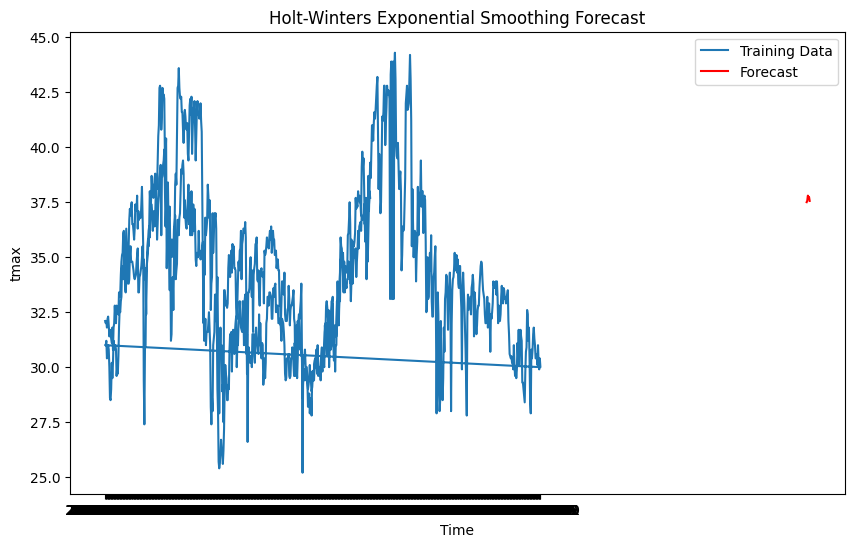

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load the dataset
train = pd.read_csv('train_datatk.csv')

# Reset the index (if the time column is already set as the index)
train_reset = train.reset_index()



# Set 'time' column as index again
train_reset.set_index('time', inplace=True)

# Apply Holt-Winters Exponential Smoothing
model = ExponentialSmoothing(train_reset['tmax'], trend='mul', seasonal='mul', seasonal_periods=12)
model_fit = model.fit()

# Forecast future values (e.g., 12 months ahead)
forecast_steps = 6
forecast = model_fit.forecast(steps=forecast_steps)

# Plot the original data and forecast
plt.figure(figsize=(10, 6))
plt.plot(train_reset['tmax'], label='Training Data')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Holt-Winters Exponential Smoothing Forecast')
plt.xlabel('Time')
plt.ylabel('tmax')
plt.legend()
plt.show()


In [56]:
print(train.columns)



Index(['time', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'state',
       'year', 'month', 'day', 'day_of_week', 'quarter'],
      dtype='object')


In [57]:
print(train.head())  # Displays the first 5 rows by default


         time  tavg  tmin  tmax  prcp   wdir  wspd    pres      state  year  \
0  2023-01-12 23.10 15.30 32.10  0.00  82.00  6.20 1011.60  Telangana  2023   
1  2023-01-13 24.60 18.80 32.00  0.00 116.00  7.10 1012.00  Telangana  2023   
2  2023-01-14 24.60 19.10 32.10  0.00 115.00  7.00 1011.90  Telangana  2023   
3  2023-01-15 24.50 17.10 31.80  0.00  84.00  7.20 1011.10  Telangana  2023   
4  2023-01-16 24.30 17.30 32.20  0.00 132.00  8.70 1011.80  Telangana  2023   

   month  day  day_of_week  quarter  
0      1   12            3        1  
1      1   13            4        1  
2      1   14            5        1  
3      1   15            6        1  
4      1   16            0        1  


# Forecasting the next 3 months data

## Using Arima model

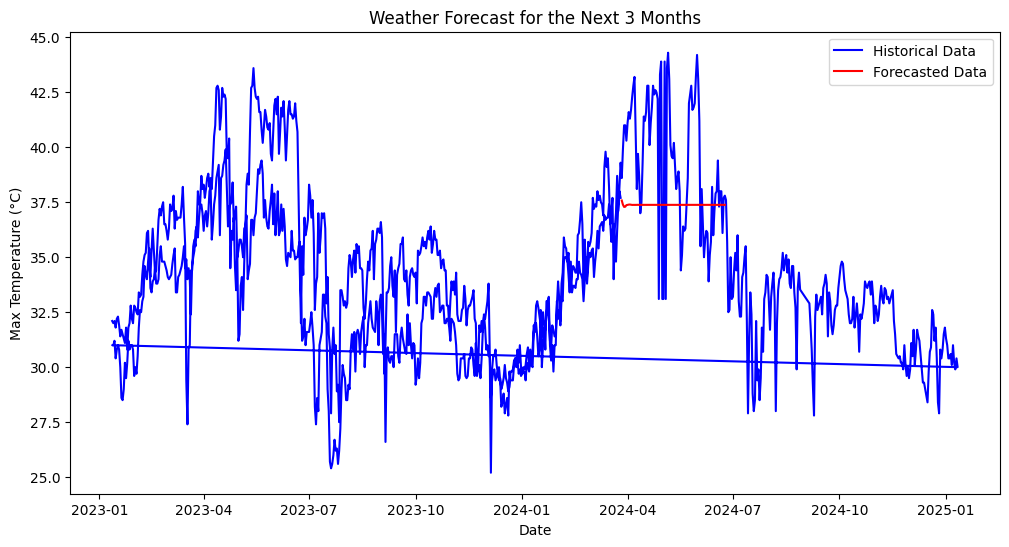

            Forecasted Temp (°C)
time                            
2024-03-27                 37.58
2024-03-28                 37.39
2024-03-29                 37.29
2024-03-30                 37.30
2024-03-31                 37.37
2024-04-01                 37.38
2024-04-02                 37.39
2024-04-03                 37.40
2024-04-04                 37.39
2024-04-05                 37.38
2024-04-06                 37.38
2024-04-07                 37.38
2024-04-08                 37.38
2024-04-09                 37.38
2024-04-10                 37.38
2024-04-11                 37.38
2024-04-12                 37.38
2024-04-13                 37.38
2024-04-14                 37.38
2024-04-15                 37.38
2024-04-16                 37.38
2024-04-17                 37.38
2024-04-18                 37.38
2024-04-19                 37.38
2024-04-20                 37.38
2024-04-21                 37.38
2024-04-22                 37.38
2024-04-23                 37.38
2024-04-24

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta

# Load your training data (Ensure 'Date' column is in datetime format)
train = pd.read_csv('train_datatk.csv', parse_dates=['time'], index_col='time')

# Fit the ARIMA model (choose appropriate p, d, q)
# Example: ARIMA(5, 1, 0), you can tune these parameters later
model = ARIMA(train['tmax'], order=(5, 1, 0))
model_fit = model.fit()

# Forecast the next 90 days (next 3 months)
forecast_steps = 90
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates
forecast_dates = [train.index[-1] + timedelta(days=i) for i in range(1, forecast_steps + 1)]
forecast_df = pd.DataFrame({'time': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('time', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['tmax'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast for the Next 3 Months')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)


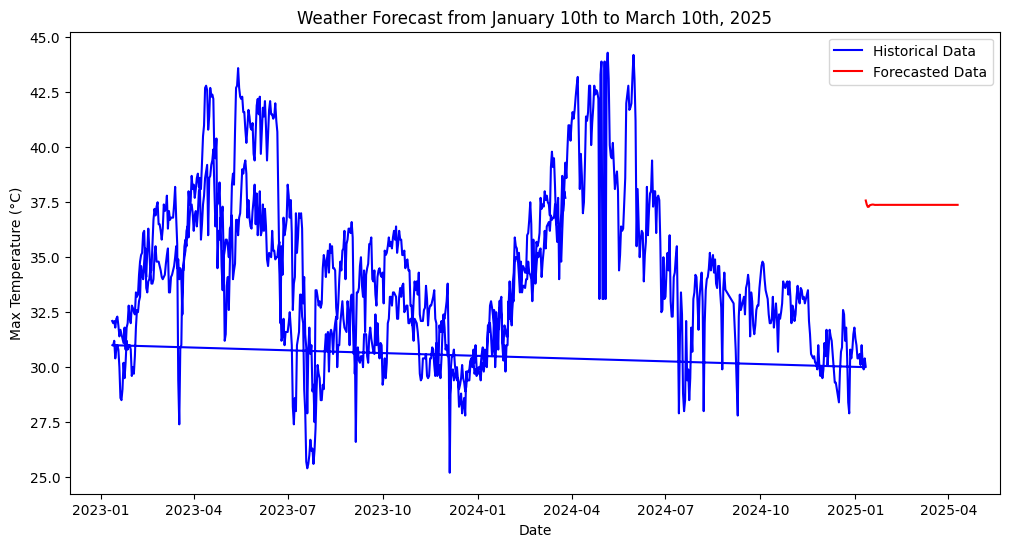

            Forecasted Temp (°C)
time                            
2025-01-11                 37.58
2025-01-12                 37.39
2025-01-13                 37.29
2025-01-14                 37.30
2025-01-15                 37.37
2025-01-16                 37.38
2025-01-17                 37.39
2025-01-18                 37.40
2025-01-19                 37.39
2025-01-20                 37.38
2025-01-21                 37.38
2025-01-22                 37.38
2025-01-23                 37.38
2025-01-24                 37.38
2025-01-25                 37.38
2025-01-26                 37.38
2025-01-27                 37.38
2025-01-28                 37.38
2025-01-29                 37.38
2025-01-30                 37.38
2025-01-31                 37.38
2025-02-01                 37.38
2025-02-02                 37.38
2025-02-03                 37.38
2025-02-04                 37.38
2025-02-05                 37.38
2025-02-06                 37.38
2025-02-07                 37.38
2025-02-08

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta

# Load your training data (Ensure 'time' column is in datetime format)
train = pd.read_csv('train_datatk.csv', parse_dates=['time'], index_col='time')

# Fit the ARIMA model (choose appropriate p, d, q)
# Example: ARIMA(5, 1, 0), you can tune these parameters later
model = ARIMA(train['tmax'], order=(5, 1, 0))
model_fit = model.fit()

# Forecast the next 90 days (from Jan 10th, 2025 to Mar 10th, 2025)
forecast_steps = 90
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates starting from Jan 10th, 2025
forecast_start_date = pd.to_datetime('2025-01-10')  # Start from Jan 10th, 2025
forecast_dates = [forecast_start_date + timedelta(days=i) for i in range(1, forecast_steps + 1)]
forecast_df = pd.DataFrame({'time': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('time', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['tmax'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast from January 10th to March 10th, 2025')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)


## Sarima model

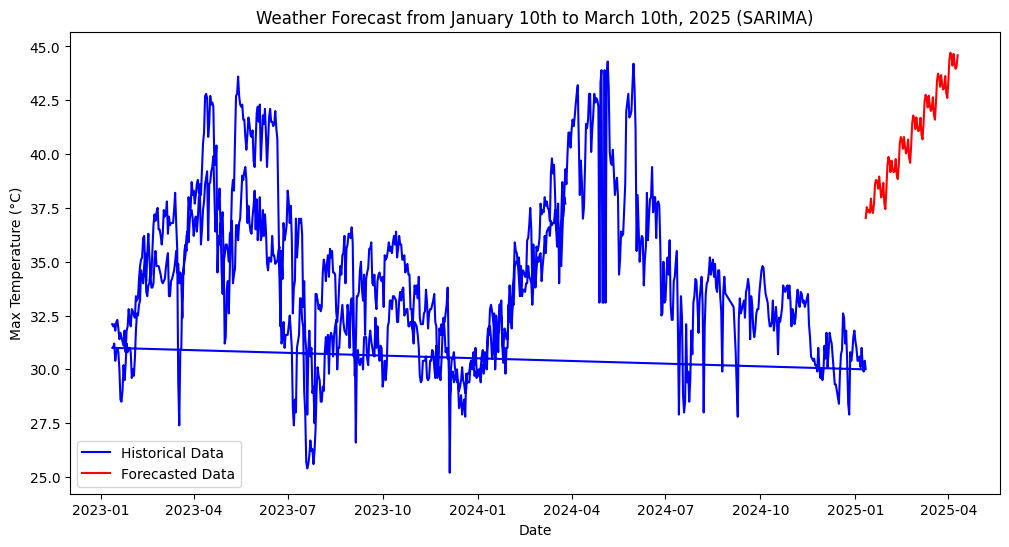

            Forecasted Temp (°C)
time                            
2025-01-11                 37.03
2025-01-12                 37.54
2025-01-13                 37.33
2025-01-14                 37.40
2025-01-15                 37.27
2025-01-16                 37.93
2025-01-17                 37.39
2025-01-18                 37.26
2025-01-19                 37.70
2025-01-20                 38.62
2025-01-21                 38.80
2025-01-22                 38.71
2025-01-23                 38.40
2025-01-24                 38.96
2025-01-25                 38.43
2025-01-26                 37.99
2025-01-27                 38.19
2025-01-28                 38.66
2025-01-29                 37.72
2025-01-30                 37.45
2025-01-31                 38.39
2025-02-01                 39.47
2025-02-02                 39.87
2025-02-03                 39.67
2025-02-04                 39.16
2025-02-05                 39.69
2025-02-06                 39.34
2025-02-07                 39.16
2025-02-08

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import timedelta

# Load your training data (Ensure 'time' column is in datetime format)
train = pd.read_csv('train_datatk.csv', parse_dates=['time'], index_col='time')

# Fit the SARIMA model (choose appropriate order and seasonal order)
# Example: SARIMAX with order (p, d, q) and seasonal_order (P, D, Q, S)
# You can adjust these parameters based on your data
# In this example, let's assume seasonal period S=12 (monthly data)
model = SARIMAX(train['tmax'], 
                order=(5, 1, 0),  # Non-seasonal ARIMA order
                seasonal_order=(1, 1, 0, 12),  # Seasonal ARIMA order (P, D, Q, S)
                enforce_stationarity=False, 
                enforce_invertibility=False)
model_fit = model.fit()

# Forecast the next 90 days (from Jan 10th, 2025 to Mar 10th, 2025)
forecast_steps = 90
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates starting from Jan 10th, 2025
forecast_start_date = pd.to_datetime('2025-01-10')  # Start from Jan 10th, 2025
forecast_dates = [forecast_start_date + timedelta(days=i) for i in range(1, forecast_steps + 1)]
forecast_df = pd.DataFrame({'time': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('time', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['tmax'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast from January 10th to March 10th, 2025 (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)


## Holt-winters exponential smoothing

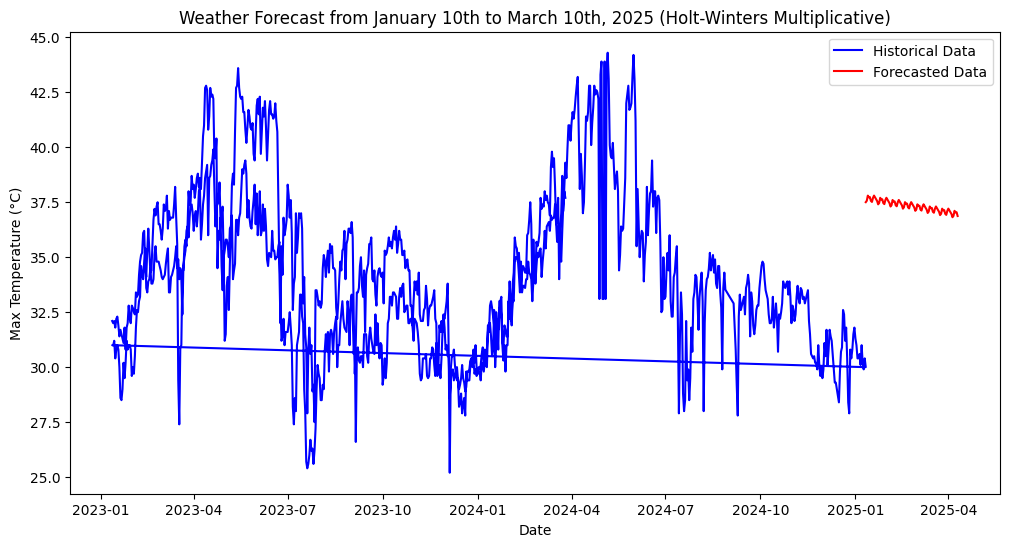

            Forecasted Temp (°C)
time                            
2025-01-11                 37.50
2025-01-12                 37.57
2025-01-13                 37.80
2025-01-14                 37.73
2025-01-15                 37.73
2025-01-16                 37.56
2025-01-17                 37.51
2025-01-18                 37.70
2025-01-19                 37.80
2025-01-20                 37.72
2025-01-21                 37.64
2025-01-22                 37.56
2025-01-23                 37.41
2025-01-24                 37.47
2025-01-25                 37.70
2025-01-26                 37.63
2025-01-27                 37.64
2025-01-28                 37.46
2025-01-29                 37.42
2025-01-30                 37.60
2025-01-31                 37.70
2025-02-01                 37.62
2025-02-02                 37.54
2025-02-03                 37.46
2025-02-04                 37.31
2025-02-05                 37.37
2025-02-06                 37.60
2025-02-07                 37.53
2025-02-08

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta

# Load your training data (Ensure 'time' column is in datetime format)
train = pd.read_csv('train_datatk.csv', parse_dates=['time'], index_col='time')

# Fit the Holt-Winters Exponential Smoothing model with multiplicative trend and seasonality
# Example: Multiplicative trend and seasonal components, with period = 12 (monthly data seasonality)
model = ExponentialSmoothing(train['tmax'], 
                             trend='mul',  # Multiplicative trend component
                             seasonal='mul',  # Multiplicative seasonal component
                             seasonal_periods=12)  # Seasonality period (e.g., 12 for monthly data)
model_fit = model.fit()

# Forecast the next 90 days (from Jan 10th, 2025 to Mar 10th, 2025)
forecast_steps = 90
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates starting from Jan 10th, 2025
forecast_start_date = pd.to_datetime('2025-01-10')  # Start from Jan 10th, 2025
forecast_dates = [forecast_start_date + timedelta(days=i) for i in range(1, forecast_steps + 1)]
forecast_df = pd.DataFrame({'time': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('time', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['tmax'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast from January 10th to March 10th, 2025 (Holt-Winters Multiplicative)')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)


## Combined graphs

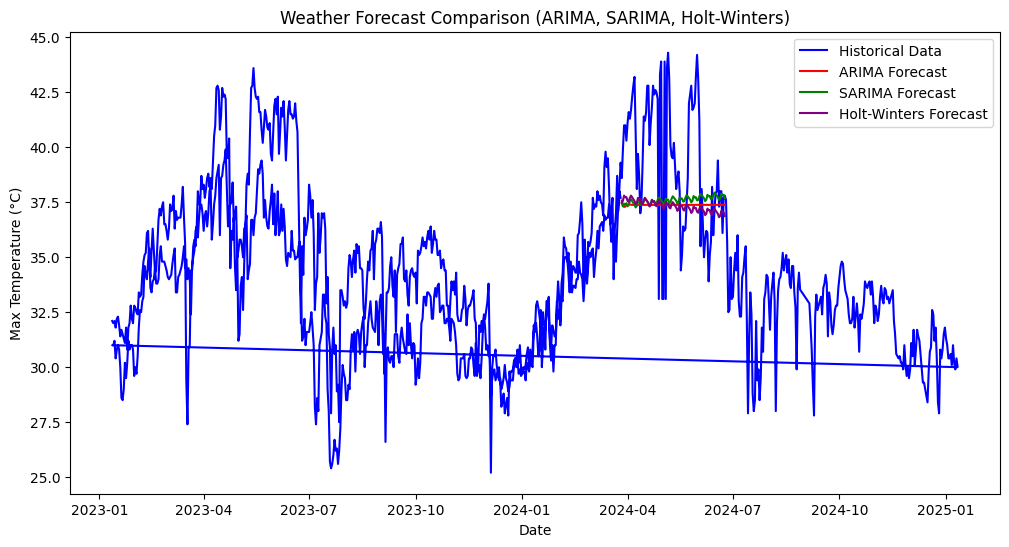

ARIMA Forecast:
            Date  ARIMA Forecast
1162 2024-03-27           37.58
1163 2024-03-28           37.39
1164 2024-03-29           37.29
1165 2024-03-30           37.30
1166 2024-03-31           37.37
1167 2024-04-01           37.38
1168 2024-04-02           37.39
1169 2024-04-03           37.40
1170 2024-04-04           37.39
1171 2024-04-05           37.38
1172 2024-04-06           37.38
1173 2024-04-07           37.38
1174 2024-04-08           37.38
1175 2024-04-09           37.38
1176 2024-04-10           37.38
1177 2024-04-11           37.38
1178 2024-04-12           37.38
1179 2024-04-13           37.38
1180 2024-04-14           37.38
1181 2024-04-15           37.38
1182 2024-04-16           37.38
1183 2024-04-17           37.38
1184 2024-04-18           37.38
1185 2024-04-19           37.38
1186 2024-04-20           37.38
1187 2024-04-21           37.38
1188 2024-04-22           37.38
1189 2024-04-23           37.38
1190 2024-04-24           37.38
1191 2024-04-25        

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta

# Load your training data (Ensure 'time' column is in datetime format)
train = pd.read_csv('train_datatk.csv', parse_dates=['time'], index_col='time')

# ARIMA Model
arima_model = ARIMA(train['tmax'], order=(5, 1, 0))  # Example: ARIMA(5, 1, 0)
arima_model_fit = arima_model.fit()
arima_forecast = arima_model_fit.forecast(steps=90)
arima_forecast_dates = [train.index[-1] + timedelta(days=i) for i in range(1, 91)]

# SARIMA Model
sarima_model = SARIMAX(train['tmax'], order=(5, 1, 0), seasonal_order=(1, 1, 1, 12))  # Example SARIMA
sarima_model_fit = sarima_model.fit()
sarima_forecast = sarima_model_fit.forecast(steps=90)
sarima_forecast_dates = [train.index[-1] + timedelta(days=i) for i in range(1, 91)]

# Holt-Winters Exponential Smoothing (Multiplicative)
holt_winters_model = ExponentialSmoothing(train['tmax'], trend='mul', seasonal='mul', seasonal_periods=12)
holt_winters_model_fit = holt_winters_model.fit()
holt_winters_forecast = holt_winters_model_fit.forecast(steps=90)
holt_winters_forecast_dates = [train.index[-1] + timedelta(days=i) for i in range(1, 91)]

# Plot all models on the same graph
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['tmax'], label='Historical Data', color='blue')

# ARIMA Forecast
plt.plot(arima_forecast_dates, arima_forecast, label='ARIMA Forecast', color='red')

# SARIMA Forecast
plt.plot(sarima_forecast_dates, sarima_forecast, label='SARIMA Forecast', color='green')

# Holt-Winters Forecast
plt.plot(holt_winters_forecast_dates, holt_winters_forecast, label='Holt-Winters Forecast', color='purple')

plt.title('Weather Forecast Comparison (ARIMA, SARIMA, Holt-Winters)')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures for each model (optional)
arima_forecast_df = pd.DataFrame({'Date': arima_forecast_dates, 'ARIMA Forecast': arima_forecast})
sarima_forecast_df = pd.DataFrame({'Date': sarima_forecast_dates, 'SARIMA Forecast': sarima_forecast})
holt_winters_forecast_df = pd.DataFrame({'Date': holt_winters_forecast_dates, 'Holt-Winters Forecast': holt_winters_forecast})

# Print dataframes for inspection
print("ARIMA Forecast:\n", arima_forecast_df)
print("SARIMA Forecast:\n", sarima_forecast_df)
print("Holt-Winters Forecast:\n", holt_winters_forecast_df)


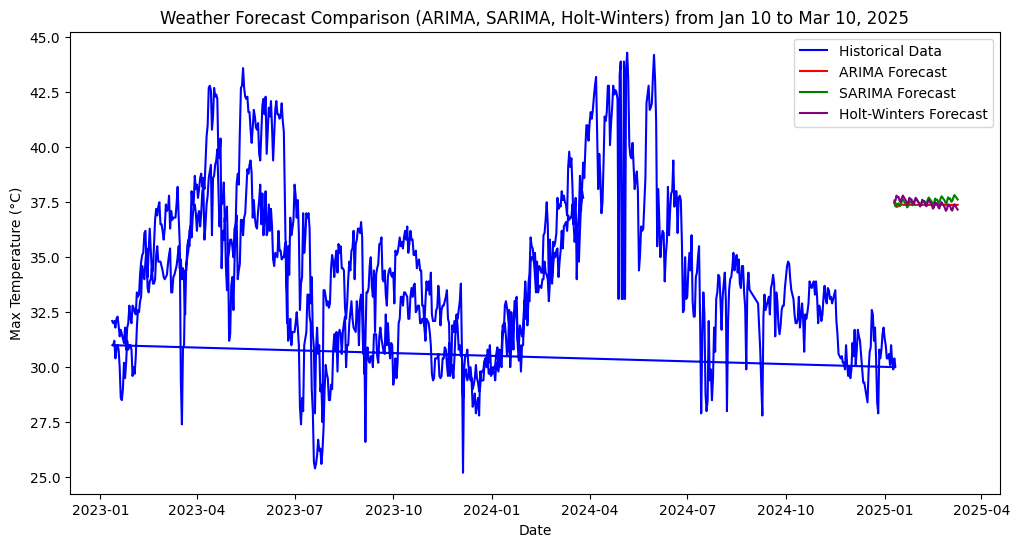

ARIMA Forecast:
            Date  ARIMA Forecast
1162 2025-01-10           37.58
1163 2025-01-11           37.39
1164 2025-01-12           37.29
1165 2025-01-13           37.30
1166 2025-01-14           37.37
1167 2025-01-15           37.38
1168 2025-01-16           37.39
1169 2025-01-17           37.40
1170 2025-01-18           37.39
1171 2025-01-19           37.38
1172 2025-01-20           37.38
1173 2025-01-21           37.38
1174 2025-01-22           37.38
1175 2025-01-23           37.38
1176 2025-01-24           37.38
1177 2025-01-25           37.38
1178 2025-01-26           37.38
1179 2025-01-27           37.38
1180 2025-01-28           37.38
1181 2025-01-29           37.38
1182 2025-01-30           37.38
1183 2025-01-31           37.38
1184 2025-02-01           37.38
1185 2025-02-02           37.38
1186 2025-02-03           37.38
1187 2025-02-04           37.38
1188 2025-02-05           37.38
1189 2025-02-06           37.38
1190 2025-02-07           37.38
1191 2025-02-08        

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta

# Load your training data (Ensure 'time' column is in datetime format)
train = pd.read_csv('train_datatk.csv', parse_dates=['time'], index_col='time')

# Define forecast period from January 10th, 2025 to March 10th, 2025
forecast_start_date = pd.to_datetime('2025-01-10')
forecast_end_date = pd.to_datetime('2025-03-10')
forecast_steps = (forecast_end_date - forecast_start_date).days + 1
forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='D')

# ARIMA Model
arima_model = ARIMA(train['tmax'], order=(5, 1, 0))  # Example: ARIMA(5, 1, 0)
arima_model_fit = arima_model.fit()
arima_forecast = arima_model_fit.forecast(steps=forecast_steps)

# SARIMA Model
sarima_model = SARIMAX(train['tmax'], order=(5, 1, 0), seasonal_order=(1, 1, 1, 12))  # Example SARIMA
sarima_model_fit = sarima_model.fit()
sarima_forecast = sarima_model_fit.forecast(steps=forecast_steps)

# Holt-Winters Exponential Smoothing (Multiplicative)
holt_winters_model = ExponentialSmoothing(train['tmax'], trend='mul', seasonal='mul', seasonal_periods=12)
holt_winters_model_fit = holt_winters_model.fit()
holt_winters_forecast = holt_winters_model_fit.forecast(steps=forecast_steps)

# Plot all models on the same graph
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['tmax'], label='Historical Data', color='blue')

# ARIMA Forecast
plt.plot(forecast_dates, arima_forecast, label='ARIMA Forecast', color='red')

# SARIMA Forecast
plt.plot(forecast_dates, sarima_forecast, label='SARIMA Forecast', color='green')

# Holt-Winters Forecast
plt.plot(forecast_dates, holt_winters_forecast, label='Holt-Winters Forecast', color='purple')

plt.title('Weather Forecast Comparison (ARIMA, SARIMA, Holt-Winters) from Jan 10 to Mar 10, 2025')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures for each model (optional)
arima_forecast_df = pd.DataFrame({'Date': forecast_dates, 'ARIMA Forecast': arima_forecast})
sarima_forecast_df = pd.DataFrame({'Date': forecast_dates, 'SARIMA Forecast': sarima_forecast})
holt_winters_forecast_df = pd.DataFrame({'Date': forecast_dates, 'Holt-Winters Forecast': holt_winters_forecast})

# Print dataframes for inspection
print("ARIMA Forecast:\n", arima_forecast_df)
print("SARIMA Forecast:\n", sarima_forecast_df)
print("Holt-Winters Forecast:\n", holt_winters_forecast_df)


## SQL connection

In [64]:
df.columns

Index(['time', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'state',
       'year', 'month', 'day', 'day_of_week', 'quarter'],
      dtype='object')

In [65]:
import mysql.connector
import pandas as pd  # Ensure pandas is imported

# Database connection details
db_config = {
    'host': 'localhost',
    'user': 'root',        # Replace with your MySQL username
    'password': 'root',    # Replace with your MySQL password
    'database': 'weather'  # Replace with your database name
}

# Connect to the database
connection = mysql.connector.connect(**db_config)
cursor = connection.cursor()

# Create the table if it doesn't exist
table_name = 'weather_data_telkar'
create_table_query = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
    time DATE,
    tavg FLOAT,
    tmin FLOAT,
    tmax FLOAT,
    prcp FLOAT,
    wdir FLOAT,
    wspd FLOAT,
    pres FLOAT,
    state VARCHAR(100),
    year INT,
    month INT,
    day INT,
    day_of_week INT,
    quarter INT
);
"""
cursor.execute(create_table_query)

# Filter required columns from DataFrame
df_to_insert = df[['time', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'state', 
                   'year', 'month', 'day', 'day_of_week', 'quarter']]

# Insert data from DataFrame into the table
insert_query = f"""
INSERT INTO {table_name} (time, tavg, tmin, tmax, prcp, wdir, wspd, pres, state, year, month, day, day_of_week, quarter)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""
data_to_insert = df_to_insert.values.tolist()  # Convert filtered DataFrame to list of tuples
cursor.executemany(insert_query, data_to_insert)

# Commit the transaction and close the connection
connection.commit()
print(f"Data inserted into table '{table_name}' successfully.")

cursor.close()
connection.close()


Data inserted into table 'weather_data_telkar' successfully.


In [66]:
#now the data is connected to the database
